# Iris Classical ML Pipeline

This notebook turns the baseline comparison into a full reproducible workflow. It starts with model benchmarking, then checks stability across random seeds, tunes the strongest candidate, and finally saves and reloads the best pipeline for a simple inference example.

The notebook is organized to answer four questions:

- Which baseline model performs best?
- Does tuning improve the strongest model?
- Is the final model stable across different splits?
- Can the trained pipeline be saved and reused safely?

The later plots show how consistent the model is, how the classes separate, and how the final tuned classifier behaves on the held-out test set.


In [114]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [115]:
df = pd.read_csv(r'C:\Users\LOQ\Documents\Papers\Iris\data\iris.csv')

In [116]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Stability Check

Before tuning, the notebook measures how sensitive the baseline models are to the random train/test split. A stable model should keep a similar accuracy across different seeds, not just perform well on one favorable split.

The box plot in the next cell summarizes that spread and helps identify which model is both accurate and consistent.


In [118]:
target_col = 'species'
X = df.drop(columns=[target_col])
y = df[target_col]

In [176]:
X.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [119]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [120]:
y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [122]:
X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


In [123]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gaussian NB': GaussianNB()
}

In [124]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [125]:
def evaluate_models(model_dict, X_train, y_train, X_test, y_test, cv):
    rows = []
    fitted = {}
    for name, model in model_dict.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rows.append({
            'Model': name,
            'CV Mean Accuracy': cv_scores.mean(),
            'CV Std': cv_scores.std(),
            'Test Accuracy': accuracy_score(y_test, y_pred)
        })
        fitted[name] = model
    results = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
    return results, fitted

In [126]:
baseline_results, baseline_fitted = evaluate_models(models, X_train, y_train, X_test, y_test, cv)
baseline_results

,Model,CV Mean Accuracy,CV Std,Test Accuracy
0,Gaussian NB,0.950000,0.016667,0.966667
1,SVM (RBF),0.966667,0.016667,0.966667
2,KNN,0.958333,0.026352,0.933333
3,Logistic Regression,0.958333,0.026352,0.933333
4,Decision Tree,0.950000,0.016667,0.933333
5,Random Forest,0.950000,0.031180,0.900000


In [127]:
baseline_best_name = baseline_results.loc[0, 'Model']
print(f'Baseline best model: {baseline_best_name}')

Baseline best model: Gaussian NB


In [128]:
seed_rows = []
seeds = [7, 21, 42, 99, 123]

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y_encoded, test_size=0.2, random_state=seed, stratify=y_encoded
    )
    seed_results, y = evaluate_models(models, X_train_s, y_train_s, X_test_s, y_test_s, cv)
    seed_results['Seed'] = seed
    seed_rows.append(seed_results)
seed_rows

[                 Model  CV Mean Accuracy    CV Std  Test Accuracy  Seed
 0  Logistic Regression          0.941667  0.056519       1.000000     7
 1                  KNN          0.925000  0.061237       1.000000     7
 2            SVM (RBF)          0.933333  0.067700       1.000000     7
 3        Random Forest          0.933333  0.050000       1.000000     7
 4          Gaussian NB          0.933333  0.050000       1.000000     7
 5        Decision Tree          0.933333  0.050000       0.933333     7,
                  Model  CV Mean Accuracy    CV Std  Test Accuracy  Seed
 0  Logistic Regression          0.950000  0.048591       0.966667    21
 1        Decision Tree          0.933333  0.042492       0.966667    21
 2        Random Forest          0.950000  0.031180       0.966667    21
 3            SVM (RBF)          0.958333  0.045644       0.966667    21
 4          Gaussian NB          0.950000  0.061237       0.966667    21
 5                  KNN          0.925000  0.04859

In [129]:
stability_df = pd.concat(seed_rows, ignore_index=True)
stability_summary = (
    stability_df.groupby('Model')['Test Accuracy']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .reset_index()
    .rename(columns={'mean': 'Mean Test Acc', 'std': 'Std', 'min': 'Min', 'max': 'Max'})
)

stability_summary

,Model,Mean Test Acc,Std,Min,Max
0,Gaussian NB,0.973333,0.014907,0.966667,1.000000
1,SVM (RBF),0.966667,0.023570,0.933333,1.000000
2,Logistic Regression,0.960000,0.027889,0.933333,1.000000
3,Random Forest,0.953333,0.038006,0.900000,1.000000
4,KNN,0.940000,0.043461,0.900000,1.000000
5,Decision Tree,0.926667,0.054772,0.833333,0.966667


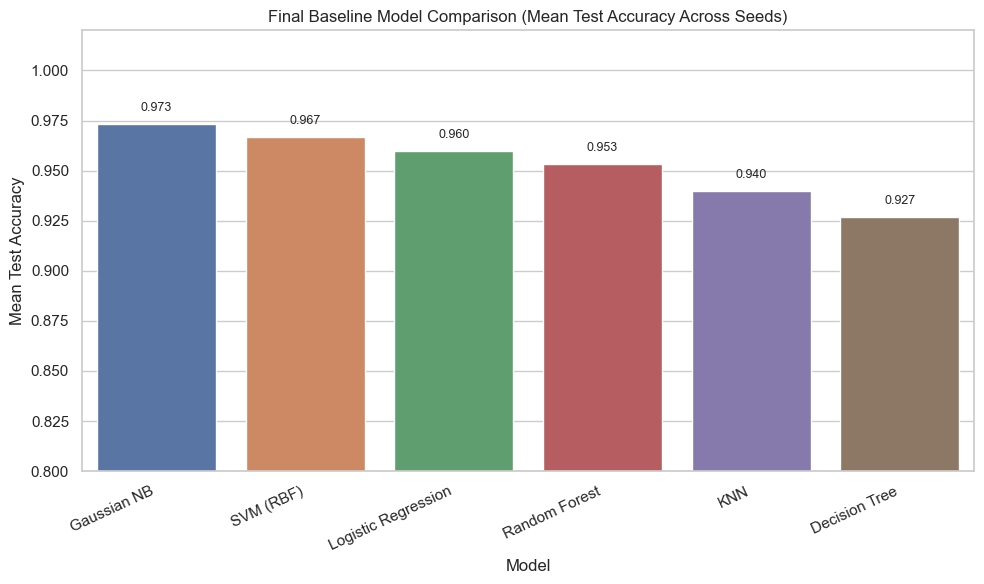

In [182]:
plot_df = stability_summary.sort_values('Mean Test Acc', ascending=False).copy()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df,
    x='Model',
    y='Mean Test Acc',
    hue='Model',
    legend=False
 )
plt.ylim(0.80, 1.02)
plt.title('Final Baseline Model Comparison (Mean Test Accuracy Across Seeds)')
plt.xlabel('Model')
plt.ylabel('Mean Test Accuracy')
plt.xticks(rotation=25, ha='right')

for i, v in enumerate(plot_df['Mean Test Acc']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

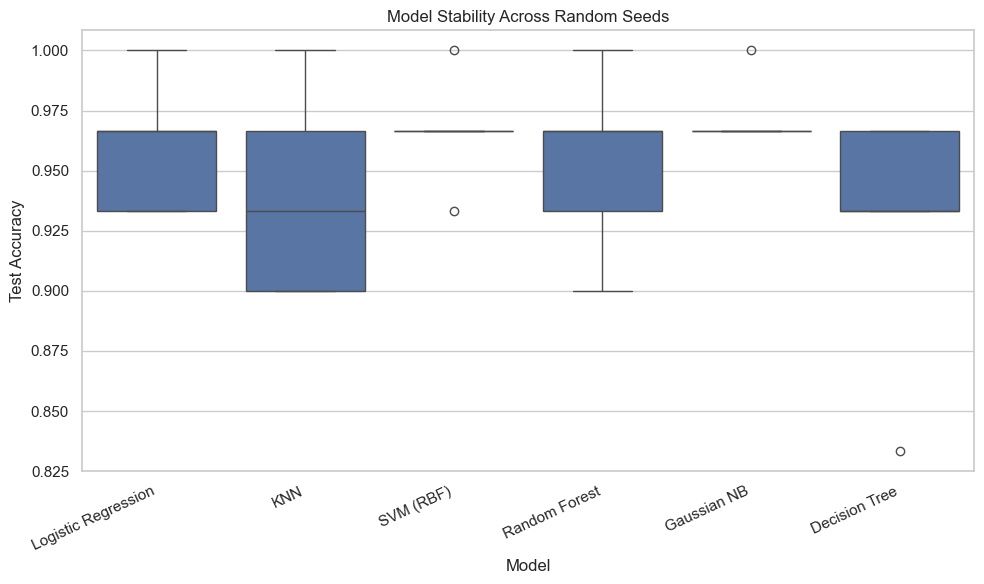

In [130]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=stability_df, x='Model', y='Test Accuracy')
plt.xticks(rotation=25, ha='right')
plt.title('Model Stability Across Random Seeds')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Tune the strongest baseline models and compare tuned vs untuned performance.


In [131]:
candidate_models = {
    'SVM (RBF)': models['SVM (RBF)'],
    'Random Forest': models['Random Forest'],
    'KNN': models['KNN'],
    'Gaussian NB': models['Gaussian NB'],
    'Logistic Regression': models['Logistic Regression'],
    'Decision Tree': models['Decision Tree'],
}

param_spaces = {
    'SVM (RBF)': {
        'model__C': np.logspace(-2, 2, 15),
        'model__gamma': np.logspace(-3, 1, 15)
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 3, 5, 8, 12],
        'min_samples_split': [2, 4, 6, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'KNN': {
        'model__n_neighbors': list(range(3, 16)),
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Gaussian NB': {
        'var_smoothing': np.logspace(-12, -7, 50)
    },
    'Logistic Regression': {
        'model__C': np.logspace(-3, 2, 20),
        'model__solver': ['lbfgs', 'liblinear', 'saga'],
        'model__penalty': ['l2']
    },
    'Decision Tree': {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 2, 3, 4, 5, 8, 12],
        'min_samples_split': [2, 4, 6, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

In [132]:
tuned_models = {}
tuned_rows = []

for name, model in candidate_models.items():
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_spaces[name],
        n_iter=20,
        scoring='accuracy',
        cv=5,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    tuned_models[name] = best_model
    tuned_rows.append({
        'Model': name,
        'Best CV Accuracy': search.best_score_,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Best Params': search.best_params_
    })

tuned_results = pd.DataFrame(tuned_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
tuned_results[['Model', 'Best CV Accuracy', 'Test Accuracy']]

,Model,Best CV Accuracy,Test Accuracy
0,SVM (RBF),0.975000,1.000000
1,KNN,0.966667,1.000000
2,Random Forest,0.958333,0.966667
3,Gaussian NB,0.958333,0.966667
4,Logistic Regression,0.966667,0.966667
5,Decision Tree,0.941667,0.933333


In [133]:
tuned_results[['Model', 'Best Params']]

,Model,Best Params
0,SVM (RBF),"{'model__gamma': 0.013894954943731374, 'model_..."
1,KNN,"{'model__weights': 'distance', 'model__n_neigh..."
2,Random Forest,"{'n_estimators': 300, 'min_samples_split': 10,..."
3,Gaussian NB,{'var_smoothing': 2.1209508879201924e-11}
4,Logistic Regression,"{'model__solver': 'lbfgs', 'model__penalty': '..."
5,Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 1..."


In [134]:
baseline_compare = baseline_results[['Model', 'Test Accuracy']].copy()
baseline_compare = baseline_compare.rename(columns={'Test Accuracy': 'Baseline Test Accuracy'})

tuned_compare = tuned_results[['Model', 'Test Accuracy']].copy()
tuned_compare = tuned_compare.rename(columns={'Test Accuracy': 'Tuned Test Accuracy'})

comparison_df = baseline_compare.merge(tuned_compare, on='Model', how='left')
comparison_df['Improvement'] = comparison_df['Tuned Test Accuracy'] - comparison_df['Baseline Test Accuracy']
comparison_df.sort_values('Baseline Test Accuracy', ascending=False)

,Model,Baseline Test Accuracy,Tuned Test Accuracy,Improvement
0,Gaussian NB,0.966667,0.966667,0.000000
1,SVM (RBF),0.966667,1.000000,0.033333
2,KNN,0.933333,1.000000,0.066667
3,Logistic Regression,0.933333,0.966667,0.033333
4,Decision Tree,0.933333,0.933333,0.000000
5,Random Forest,0.900000,0.966667,0.066667


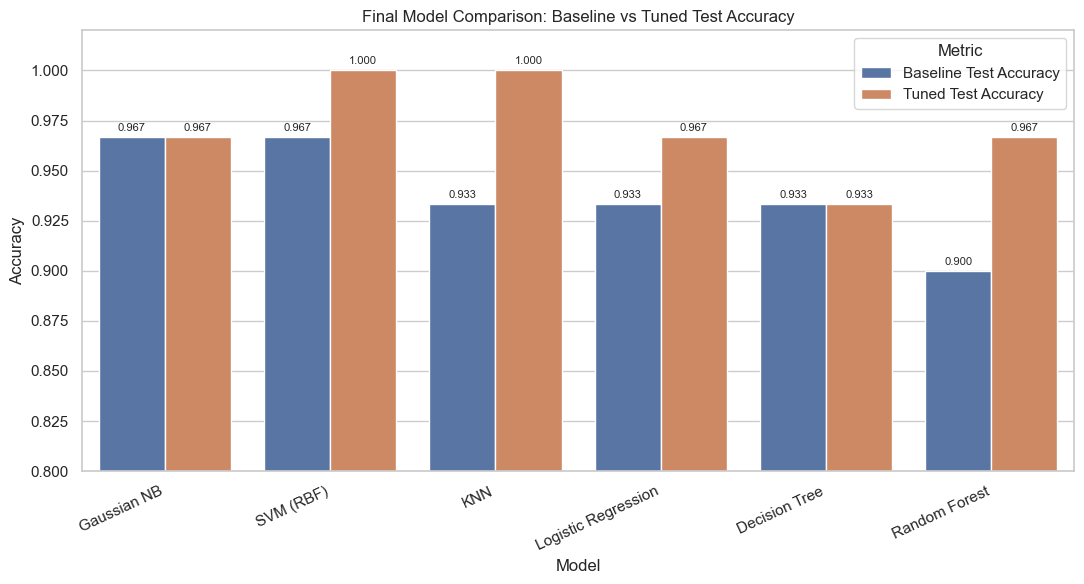

,Model,Baseline Test Accuracy,Tuned Test Accuracy,Improvement
0,Gaussian NB,0.966667,0.966667,0.000000
1,SVM (RBF),0.966667,1.000000,0.033333
2,KNN,0.933333,1.000000,0.066667
3,Logistic Regression,0.933333,0.966667,0.033333
4,Decision Tree,0.933333,0.933333,0.000000
5,Random Forest,0.900000,0.966667,0.066667


In [185]:
final_cmp = comparison_df[['Model', 'Baseline Test Accuracy', 'Tuned Test Accuracy', 'Improvement']].copy()
final_cmp = final_cmp.sort_values('Baseline Test Accuracy', ascending=False)

plot_df = final_cmp.melt(
    id_vars='Model',
    value_vars=['Baseline Test Accuracy', 'Tuned Test Accuracy'],
    var_name='Metric',
    value_name='Accuracy'
 ).dropna()

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Metric')
plt.ylim(0.80, 1.02)
plt.title('Final Model Comparison: Baseline vs Tuned Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=25, ha='right')

for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h):
        ax.annotate(f'{h:.3f}',
                    (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                    textcoords='offset points')

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

final_cmp

In [135]:
final_candidates = []

# Best baseline
base_best_name = baseline_results.loc[0, 'Model']
final_candidates.append((base_best_name, baseline_fitted[base_best_name], 'baseline'))

# Best tuned
tuned_best_name = tuned_results.loc[0, 'Model']
final_candidates.append((tuned_best_name, tuned_models[tuned_best_name], 'tuned'))

best_name, best_model, best_source = max(
    final_candidates,
    key=lambda x: accuracy_score(y_test, x[1].predict(X_test))
)

best_pred = best_model.predict(X_test)
best_test_acc = accuracy_score(y_test, best_pred)

print(f'Final selected model: {best_name} ({best_source})')
print(f'Final test accuracy: {best_test_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))


Final selected model: SVM (RBF) (tuned)
Final test accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



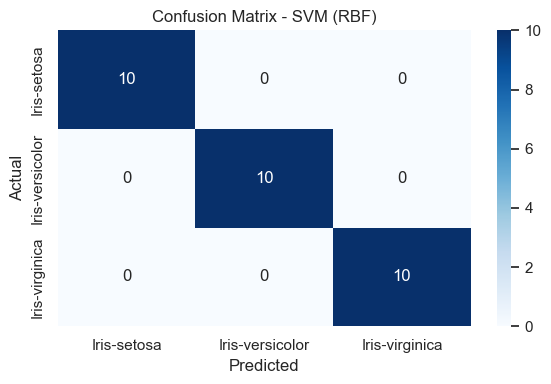

In [136]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
    )
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
model_for_insight = best_model

if isinstance(model_for_insight, Pipeline):
    estimator = model_for_insight.named_steps['model']
else:
    estimator = model_for_insight

feature_names = X.columns.tolist()

if hasattr(estimator, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': estimator.feature_importances_
    }).sort_values('Importance', ascending=False)
    display(importance_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {best_name}')
    plt.tight_layout()
    plt.show()

elif hasattr(estimator, 'coef_'):
    coef_abs = np.abs(estimator.coef_)
    if coef_abs.ndim == 2:
        coef_abs = coef_abs.mean(axis=0)
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Abs Coefficient': coef_abs
    }).sort_values('Abs Coefficient', ascending=False)
    display(coef_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=coef_df, x='Abs Coefficient', y='Feature')
    plt.title(f'Coefficient Magnitude - {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print('This model does not provide direct feature importance or coefficients.')

This model does not provide direct feature importance or coefficients.


In [150]:
best_model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,np.float64(26.826957952797247)
,kernel,'rbf'
,degree,3
,gamma,np.float64(0....4954943731374)


In [151]:
artifacts = {
    'model': best_model,
    'label_encoder': label_encoder,
    'feature_names': X.columns.tolist()
}

artifact_path = Path(r'C:\Users\LOQ\Documents\Papers\Iris\artifacts\iris_best_pipeline.joblib')
joblib.dump(artifacts, artifact_path)
print(f'Saved to: {artifact_path.resolve()}')

Saved to: C:\Users\LOQ\Documents\Papers\Iris\artifacts\iris_best_pipeline.joblib


In [166]:
X_test.shape

(30, 4)

In [169]:
loaded = joblib.load(r'C:\Users\LOQ\Documents\Papers\Iris\artifacts\iris_best_pipeline.joblib')
loaded_model = loaded['model']
loaded_encoder = loaded['label_encoder']
loaded_features = loaded['feature_names']

import random 
rd = random.randint(0,29)
print(f"Randomly selected test sample index: {rd}")
sample = X_test.iloc[[rd]][loaded_features]
pred_encoded = loaded_model.predict(sample)[0]
pred_label = loaded_encoder.inverse_transform([pred_encoded])[0]

print("Sample input:")
sample


Randomly selected test sample index: 3
Sample input:


,sepal_length,sepal_width,petal_length,petal_width
93,5.0,2.3,3.3,1.0


In [170]:
print(f'Predicted class: {pred_label}')

Predicted class: Iris-versicolor


## Additional Visualizations and Interaction

The final section adds more context for the tuned model. The feature-mean heatmap shows how the species differ on average, the pair plot shows class separation across all feature combinations, and the widget provides a lightweight interactive view for exploring two features at a time.

These visuals are useful for explaining why the tuned SVM works well on this dataset and for communicating the result in a report or presentation.


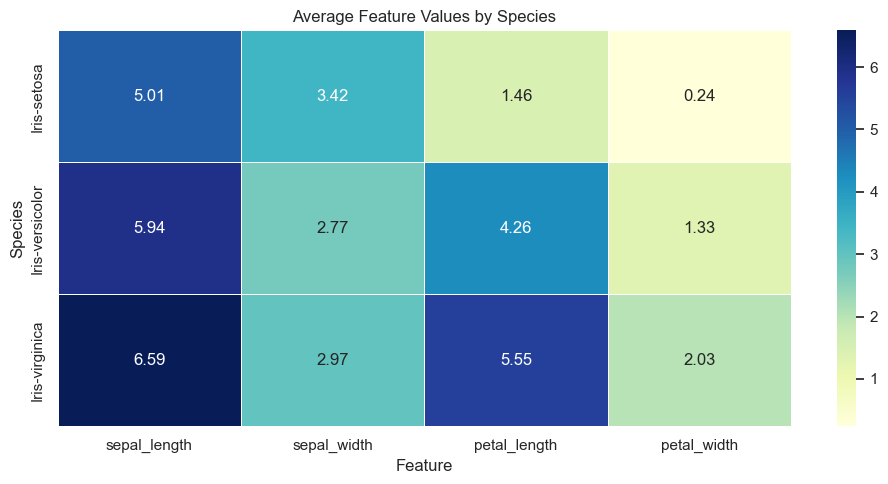

In [171]:
feature_cols = X.columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df.groupby(target_col)[feature_cols].mean(),
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
    )
plt.title('Average Feature Values by Species')
plt.xlabel('Feature')
plt.ylabel('Species')
plt.tight_layout()
plt.show()


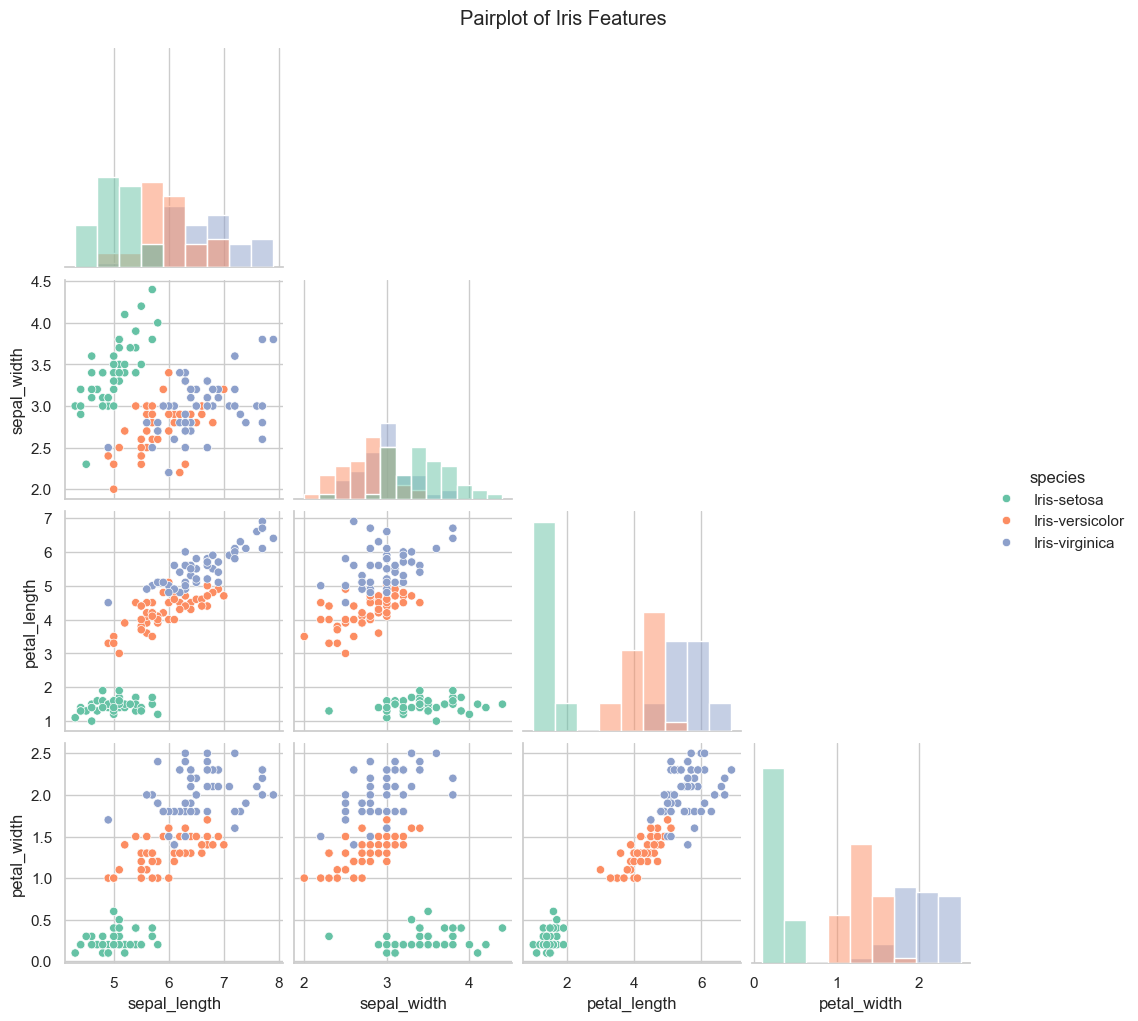

In [172]:
sns.pairplot(df, hue=target_col, corner=True, diag_kind='hist', palette='Set2')
plt.Figure(figsize=(10, 10))
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

In [ ]:
widgets = __import__('ipywidgets')

def show_scatter(x_feature, y_feature):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=x_feature, y=y_feature, hue=target_col, s=70, palette='Set2')
    plt.title(f'{x_feature} vs {y_feature}')
    plt.tight_layout()
    plt.show()

widgets.interact(
    show_scatter,
    x_feature=widgets.Dropdown(options=feature_cols, value=feature_cols[0], description='X axis:'),
        y_feature=widgets.Dropdown(options=feature_cols, value=feature_cols[1], description='Y axis:'))

interactive(children=(Dropdown(description='X axis:', options=('sepal_length', 'sepal_width', 'petal_length', …

<function __main__.show_scatter(x_feature, y_feature)>

In [174]:
widgets = __import__('ipywidgets')

from IPython.display import display, clear_output

feature_ranges = {col: (float(X[col].min()), float(X[col].max())) for col in feature_cols}

sliders = {
        col: widgets.FloatSlider(
            value=float(X.iloc[0][col]),
            min=feature_ranges[col][0],
            max=feature_ranges[col][1],
            step=0.1,
            description=col
        )
        for col in feature_cols
    }

predict_button = widgets.Button(description='Predict Species', button_style='success')
output_area = widgets.Output()

def on_predict_clicked(_):
    sample = pd.DataFrame([{col: sliders[col].value for col in feature_cols}])
    pred_encoded = best_model.predict(sample)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    with output_area:
        clear_output()
        print('Input sample:')
        display(sample)
        print(f'Predicted species: {pred_label}')
        if hasattr(best_model, 'predict_proba'):
            probs = best_model.predict_proba(sample)[0]
            prob_df = pd.DataFrame({
                    'Species': label_encoder.classes_,
                    'Probability': probs
                }).sort_values('Probability', ascending=False)
            display(prob_df)

predict_button.on_click(on_predict_clicked)
widgets.VBox(list(sliders.values()) + [predict_button, output_area])